In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeNdtExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Iris
data = load_breast_cancer()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME
explainer = LimeNdtExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Explication locale (feature, poids):
[(np.str_('worst area'), -0.9257163485513107), (np.str_('worst concave points'), -0.7204711945492345), (np.str_('worst radius'), -0.6344704758206176), (np.str_('mean concave points'), -0.5005617518227216), (np.str_('worst perimeter'), -0.47459943574143415), (np.str_('area error'), -0.12042874416705074), (np.str_('worst texture'), -0.07488313487948695), (np.str_('mean area'), -0.04396190476190481), (np.str_('mean concavity'), -0.03336700648748839), (np.str_('worst smoothness'), 0.0), (np.str_('mean radius'), 0.0), (np.str_('mean texture'), 0.0), (np.str_('mean perimeter'), 0.0), (np.str_('worst symmetry'), 0.0), (np.str_('mean smoothness'), 0.0), (np.str_('mean symmetry'), 0.0), (np.str_('compactness error'), 0.0), (np.str_('texture error'), 0.0), (np.str_('symmetry error'), 0.0), (np.str_('radius error'), 0.0), (np.str_('mean fractal dimension'), 0.0), (np.str_('worst c

In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[(np.str_('worst area'), -0.0593613436684769), (np.str_('worst concave points'), -0.04753285026147366), (np.str_('worst perimeter'), -0.04167949586040671), (np.str_('worst radius'), -0.03792976539351252), (np.str_('mean concave points'), -0.030087690301213967), (np.str_('area error'), -0.029750745689101594), (np.str_('radius error'), -0.026499272147693202), (np.str_('worst texture'), -0.026253810584859857), (np.str_('worst concavity'), -0.02423617186952391), (np.str_('mean texture'), -0.02312951393852905), (np.str_('mean concavity'), -0.02001448879690205), (np.str_('mean area'), -0.013805719288721189), (np.str_('mean radius'), -0.010701314202893077), (np.str_('worst symmetry'), -0.010253493785393825), (np.str_('worst smoothness'), -0.010008711522269589), (np.str_('mean perimeter'), -0.007471244233890814), (np.str_('symmetry error'), 0.007445858884642885), (np.str_('mean smoothness'), -0.006016761349375027), (np.str_('frac

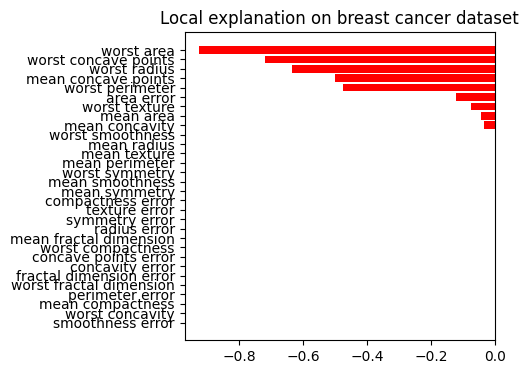

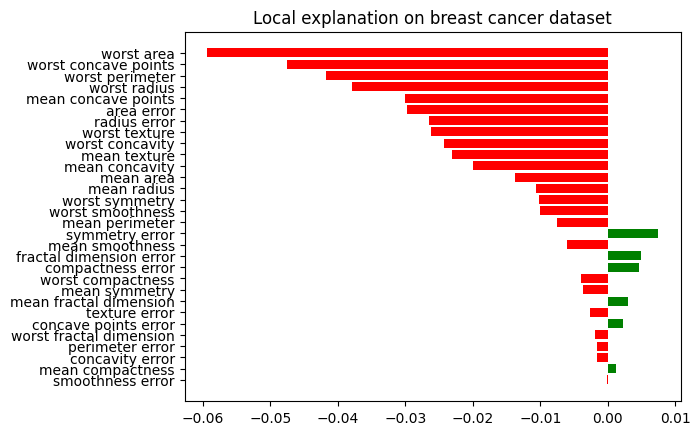

In [4]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on breast cancer dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on breast cancer dataset")
plt.show()


Local explanation with DecisionTreeRegressor surrogate (feature, weight):
[(np.str_('worst area'), -0.24378413257584142), (np.str_('worst concave points'), -0.13861817077890384), (np.str_('worst perimeter'), -0.10990479991846937), (np.str_('worst radius'), -0.10494811063992854), (np.str_('mean concave points'), -0.054945838173479006), (np.str_('area error'), -0.053839425035944306), (np.str_('worst concavity'), -0.041928498575629844), (np.str_('radius error'), -0.03584896664954266), (np.str_('mean texture'), -0.031776265668587836), (np.str_('worst texture'), -0.026561498608553127), (np.str_('mean concavity'), -0.024944681844854225), (np.str_('mean area'), -0.012908460063231684), (np.str_('mean radius'), -0.011489082217764643), (np.str_('worst smoothness'), -0.009080216595588834), (np.str_('worst symmetry'), -0.008656930181929997), (np.str_('mean perimeter'), -0.008584995359840456), (np.str_('mean smoothness'), -0.007886033524167916), (np.str_('perimeter error'), -0.007412633357674122),

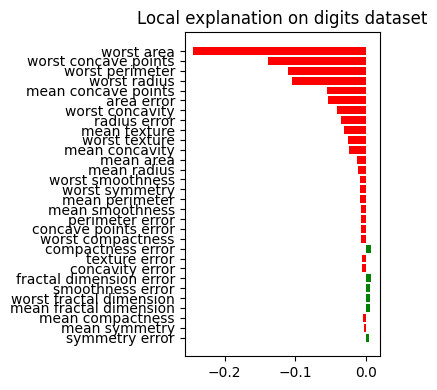

In [5]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

# --- Custom wrapper class ---
class SignedDecisionTreeRegressorWrapper(DecisionTreeRegressor):
    """
    DecisionTreeRegressor wrapper for LIME that produces signed coefficients
    based on local feature–target correlations.
    """
    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight=sample_weight)
        importances = np.array(self.feature_importances_)
        
        # Compute correlation signs between X_j and y
        signs = np.zeros_like(importances)
        for j in range(X.shape[1]):
            corr = np.corrcoef(X[:, j], y)[0, 1]
            signs[j] = np.sign(corr) if not np.isnan(corr) else 0
        
        # Combine magnitude (importance) with direction (sign)
        signed_importances = importances * signs
        
        # Normalize
        if np.sum(np.abs(signed_importances)) > 0:
            signed_importances = signed_importances / np.sum(np.abs(signed_importances))
        
        self.coef_ = signed_importances
        self.intercept_ = np.array([np.mean(y)])
        return self

# --- Instantiate and use in LIME ---
local_dt = SignedDecisionTreeRegressorWrapper(max_depth=30, random_state=0)

exp_dt = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=30,
    model_regressor=local_dt
)

print("\nLocal explanation with DecisionTreeRegressor surrogate (feature, weight):")
print(exp_dt.as_list())

fig_dt = exp_dt.as_pyplot_figure()
fig_dt.axes[0].set_title("Local explanation on digits dataset")
plt.tight_layout()
plt.show()
